In [1]:
import pandeia.engine
import stsynphot
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import os, glob, sys
import numpy as np
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from rsg import rsg_phot
%matplotlib inline

In [2]:
syn_rsg = rsg_phot()
rsgspec = syn_rsg.create_rsg(1, 2, 3500, 1000)
filts = ['f070w', 'f090w', 'f115w', 'f150w', 'f182m', 'f200w', 'f210m', 'f277w', 'f335m', 'f356w', 'f444w']
rsgmag = syn_rsg.compute_rsg_mag(filts, 1, 2, 3500, 1000)

Text(0, 0.5, 'Flux (PHOTLAM)')

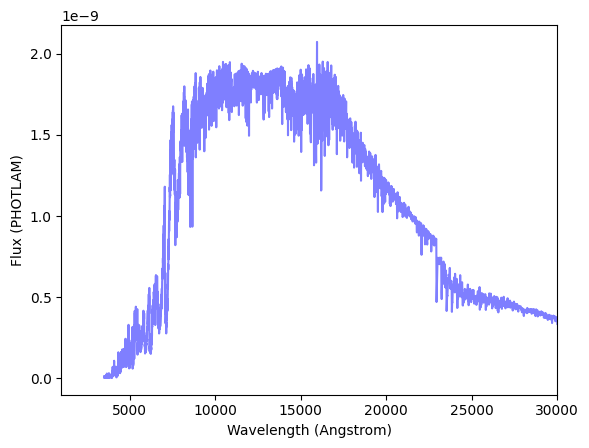

In [3]:
wvs = rsgspec.waveset
plt.plot(wvs, rsgspec(wvs), color = 'blue', alpha = 0.5)
plt.xlim(1000, 30000)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux (PHOTLAM)')

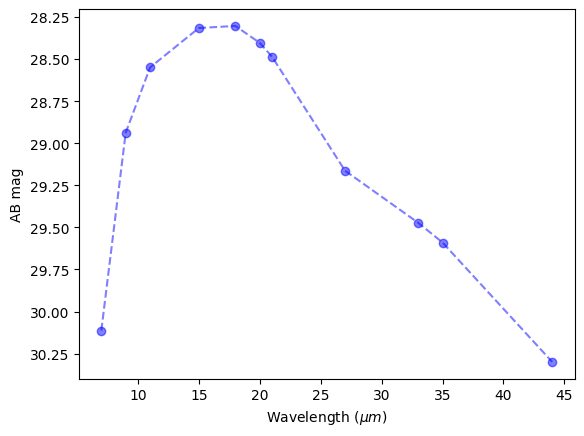

In [4]:
wvs = [float(i[1:3]) for i in filts]
mags = [rsgmag[flt].value for flt in filts]
plt.plot(wvs, mags, color = 'blue', alpha = 0.5, marker = 'o', linestyle = '--')
plt.xlabel(r'Wavelength (${\mu}m$)')
plt.ylabel('AB mag')
plt.gca().invert_yaxis()